<a href="https://colab.research.google.com/github/DilshanBotheju/CSACP_Project/blob/main/HomicideClusterdDataset%26SML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dataset Analysis**

**1. Import Libraries**

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import pickle

**2. Load and Inspect the Dataset**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data = pd.read_csv("/content/drive/MyDrive/DSGP/homicide_serial_labeled.csv")

In [4]:
#Display information
print("Dataset Info:")
print(data.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319227 entries, 0 to 319226
Data columns (total 26 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   Year                              319227 non-null  int64  
 1   Month                             319227 non-null  int64  
 2   Victim Count                      319227 non-null  int64  
 3   Victim Age Group                  319227 non-null  int64  
 4   Date                              319227 non-null  object 
 5   Time_Diff                         319217 non-null  float64
 6   Crime_Frequency                   319227 non-null  int64  
 7   State_Crime_Category              319227 non-null  int64  
 8   Victim Sex_Female                 319227 non-null  bool   
 9   Victim Sex_Male                   319227 non-null  bool   
 10  Perpetrator Sex_Female            319227 non-null  bool   
 11  Perpetrator Sex_Male              3192

In [5]:
#Load 5 rows
print("\nFirst 5 rows:")
print(data.head())


First 5 rows:
   Year  Month  Victim Count  Victim Age Group        Date  Time_Diff  \
0  1980      1             0                 5  1980-01-01        NaN   
1  1980      1             0                 5  1980-01-01        NaN   
2  1980      1             0                 0  1980-01-01        0.0   
3  1980      1             0                 5  1980-01-01        NaN   
4  1980      1             0                 0  1980-01-01        0.0   

   Crime_Frequency  State_Crime_Category  Victim Sex_Female  Victim Sex_Male  \
0             9768                     2               True            False   
1             7086                     2              False             True   
2            12818                     0              False             True   
3            14178                     0              False             True   
4             5711                     2              False             True   

   ...  Relationship_Stepfamily  Relationship_Stranger  \
0  ... 

**3. Understand Numerical Features**

In [6]:
# View the shape of dataset
print("\nDataset Shape:")
print(data.shape)


Dataset Shape:
(319227, 26)


In [7]:
# Label encoding categorical data
label_encoder = LabelEncoder()
for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = label_encoder.fit_transform(data[column])

In [8]:
data.head()

,Year,Month,Victim Count,Victim Age Group,Date,Time_Diff,Crime_Frequency,State_Crime_Category,Victim Sex_Female,Victim Sex_Male,...,Relationship_Stepfamily,Relationship_Stranger,Relationship_Work/Employer,Weapon_Blunt Objects,Weapon_Environmental/Accidental,Weapon_Firearms,Weapon_Other,Weapon_Poisoning,Weapon_Strangulation/Suffocation,Cluster_Label
0,1980,1,0,5,0,NaN,9768,2,True,False,...,False,False,False,False,False,True,False,False,False,0
1,1980,1,0,5,0,NaN,7086,2,False,True,...,False,False,False,False,False,True,False,False,False,1
2,1980,1,0,0,0,0.0,12818,0,False,True,...,False,False,False,False,False,True,False,False,False,0
3,1980,1,0,5,0,NaN,14178,0,False,True,...,False,False,False,False,False,True,False,False,False,0
4,1980,1,0,0,0,0.0,5711,2,False,True,...,False,False,False,False,False,True,False,False,False,1


Correlations with Target Column:
Year                                0.096355
Month                               0.014098
Victim Count                        0.040318
Victim Age Group                    0.118869
Date                                0.096694
Time_Diff                          -0.046905
Crime_Frequency                    -0.019687
State_Crime_Category               -0.024845
Victim Sex_Female                  -0.233407
Victim Sex_Male                     0.233407
Perpetrator Sex_Female             -0.177480
Perpetrator Sex_Male                0.177480
Relationship_Family                -0.343287
Relationship_Friend/Acquaintance    0.681062
Relationship_Other                 -0.118403
Relationship_Partner/Spouse        -0.199085
Relationship_Stepfamily            -0.098135
Relationship_Stranger              -0.416117
Relationship_Work/Employer          0.011779
Weapon_Blunt Objects               -0.346247
Weapon_Environmental/Accidental     0.110816
Weapon_Firearms       

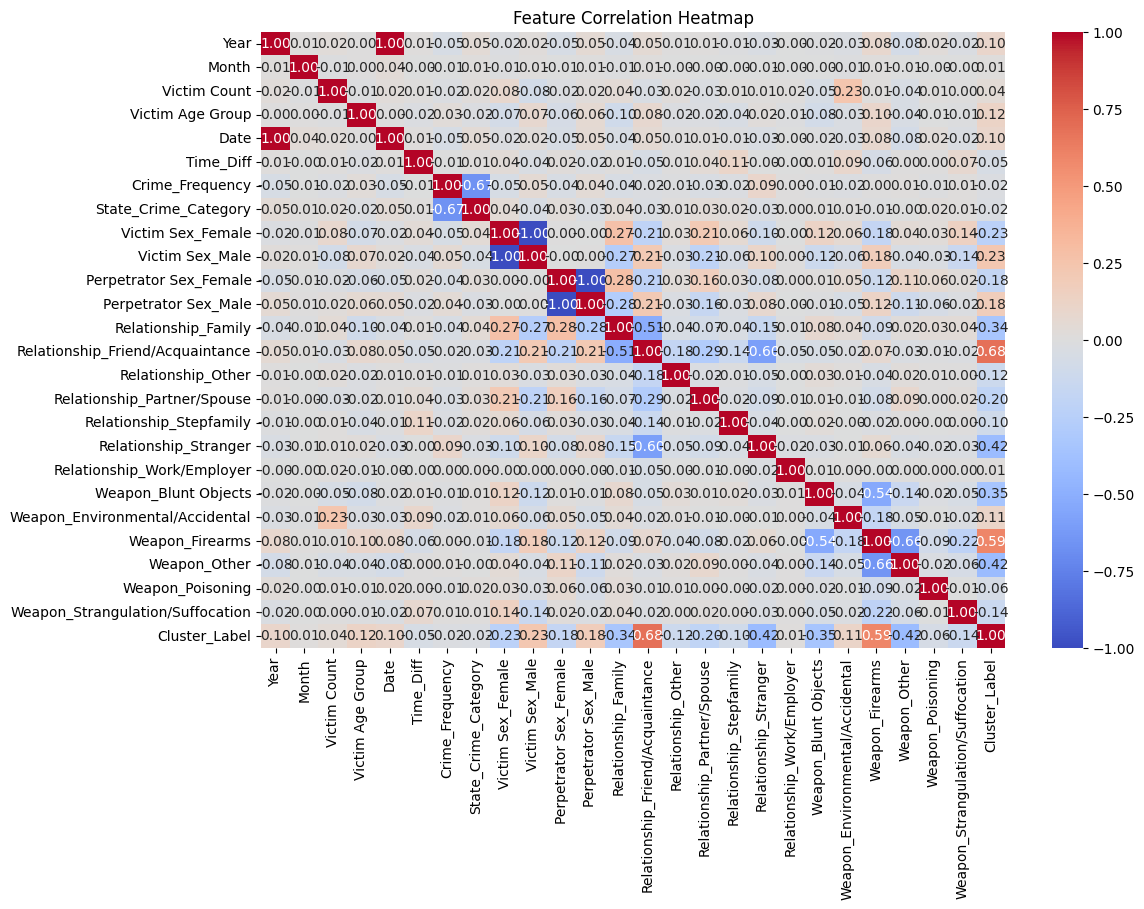

In [9]:
target_column = "Cluster_Label"

# Calculate correlations
correlations = data.corr()[target_column].drop(target_column)

# Print correlations
print("Correlations with Target Column:")
print(correlations)

# Display the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

In [10]:
import pandas as pd
from scipy.stats import pearsonr
from sklearn.preprocessing import LabelEncoder

# Load your dataset
data = pd.read_csv("/content/drive/MyDrive/DSGP/homicide_serial_labeled.csv")

# Convert 'object' type columns to numerical using Label Encoding if needed
for col in data.select_dtypes(include=['object']).columns:
    data[col] = LabelEncoder().fit_transform(data[col])

features = [
    "Time_Diff", "Crime_Frequency", "State_Crime_Category", "Victim Count",
    "Victim Sex_Female", "Perpetrator Sex_Male",
    "Relationship_Family", "Relationship_Friend/Acquaintance", "Relationship_Other",
    "Relationship_Partner/Spouse", "Relationship_Stepfamily", "Relationship_Stranger",
    "Weapon_Blunt Objects", "Weapon_Environmental/Accidental", "Weapon_Firearms",
    "Weapon_Other", "Weapon_Poisoning", "Weapon_Strangulation/Suffocation", "Victim Age Group"
]

# Calculate and print Pearson correlations
for feature in features:
    correlation, p_value = pearsonr(data[feature], data["Cluster_Label"])
    print(f"{feature}: Pearson correlation = {correlation:.3f}, p-value = {p_value:.3f}")

Time_Diff: Pearson correlation = nan, p-value = nan
Crime_Frequency: Pearson correlation = -0.020, p-value = 0.000
State_Crime_Category: Pearson correlation = -0.025, p-value = 0.000
Victim Count: Pearson correlation = 0.040, p-value = 0.000
Victim Sex_Female: Pearson correlation = -0.233, p-value = 0.000
Perpetrator Sex_Male: Pearson correlation = 0.177, p-value = 0.000
Relationship_Family: Pearson correlation = -0.343, p-value = 0.000
Relationship_Friend/Acquaintance: Pearson correlation = 0.681, p-value = 0.000
Relationship_Other: Pearson correlation = -0.118, p-value = 0.000
Relationship_Partner/Spouse: Pearson correlation = -0.199, p-value = 0.000
Relationship_Stepfamily: Pearson correlation = -0.098, p-value = 0.000
Relationship_Stranger: Pearson correlation = -0.416, p-value = 0.000
Weapon_Blunt Objects: Pearson correlation = -0.346, p-value = 0.000
Weapon_Environmental/Accidental: Pearson correlation = 0.111, p-value = 0.000
Weapon_Firearms: Pearson correlation = 0.587, p-value

# **Splitting dataset**

In [11]:
# Download feature_names.pkl file
import pickle
with open('feature_names.pkl', 'wb') as file:
    pickle.dump(list(data.columns), file)

In [12]:
# Feature selection
X = data.drop("Cluster_Label", axis=1)
y = data["Cluster_Label"]

# Train test splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 223458
Test set size: 95769


In [13]:
y.value_counts()

,count
Cluster_Label,
1,160705
0,158522


In [14]:
from collections import Counter
print(Counter(y_train))
print(Counter(y_test))


Counter({1: 112525, 0: 110933})
Counter({1: 48180, 0: 47589})


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer

# Impute missing values before scaling
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Standardscaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Shuffle target labels
y_shuffled = shuffle(y_train, random_state=42)

# Train a model with shuffled labels
model = LogisticRegression()
model.fit(X_train_scaled, y_shuffled)

# Predict on training data
y_pred_shuffled = model.predict(X_train_scaled)

acc = accuracy_score(y_shuffled, y_pred_shuffled)
print(f"\nShuffled Label Accuracy: {acc:.2f}")

if acc > 0.6:
    print("Possible Data Leakage Detected!")
else:
    print("No significant data leakage detected.")


Shuffled Label Accuracy: 0.50
No significant data leakage detected.


**19. Feature Scaling**

In [16]:
# Standardscaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#save scaler to pickle file
with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

In [17]:
from sklearn.decomposition import PCA

# Reduce the number of features for better accuracy
pca = PCA(n_components=20)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


In [18]:
# Shuffle the data
from sklearn.utils import shuffle
X_train_pca, y_train = shuffle(X_train_pca, y_train, random_state=42)


# **Model Training**


Cross-Validation Accuracy: 0.9231 ± 0.0006

Training Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92    110933
           1       0.93      0.92      0.92    112525

    accuracy                           0.92    223458
   macro avg       0.92      0.92      0.92    223458
weighted avg       0.92      0.92      0.92    223458


Testing Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92     47589
           1       0.92      0.93      0.92     48180

    accuracy                           0.92     95769
   macro avg       0.92      0.92      0.92     95769
weighted avg       0.92      0.92      0.92     95769



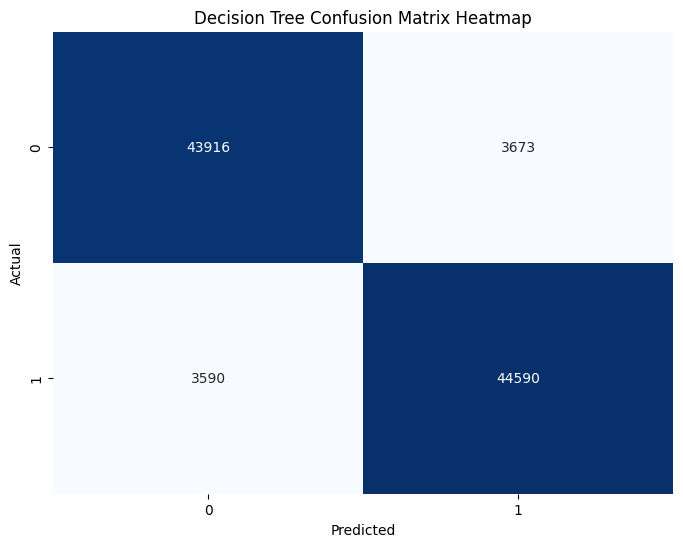

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize Decision Tree model
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=2, random_state=42)

# Cross-validation with accuracy scoring
cv_scores = cross_val_score(dt_model, X_train_pca, y_train, cv=5, scoring='accuracy')
print(f"\nCross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Fit the model
dt_model.fit(X_train_pca, y_train)

# Predictions on the training set
y_train_pred = dt_model.predict(X_train_pca)

# Predictions on the test set
y_test_pred = dt_model.predict(X_test_pca)

# Evaluation metrics for training data
print("\nTraining Classification Report:")
print(classification_report(y_train, y_train_pred))

# Evaluation metrics for testing data
print("\nTesting Classification Report:")
print(classification_report(y_test, y_test_pred))

# Confusion matrix for testing data
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix Heatmap')
plt.show()

with open('Decision_Tree_Classifier.pkl', 'wb') as file:
    pickle.dump(dt_model, file)


Cross-Validation Accuracy: 0.9806 ± 0.0006

Training Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    110933
           1       1.00      0.96      0.98    112525

    accuracy                           0.98    223458
   macro avg       0.98      0.98      0.98    223458
weighted avg       0.98      0.98      0.98    223458


Testing Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     47589
           1       1.00      0.96      0.98     48180

    accuracy                           0.98     95769
   macro avg       0.98      0.98      0.98     95769
weighted avg       0.98      0.98      0.98     95769



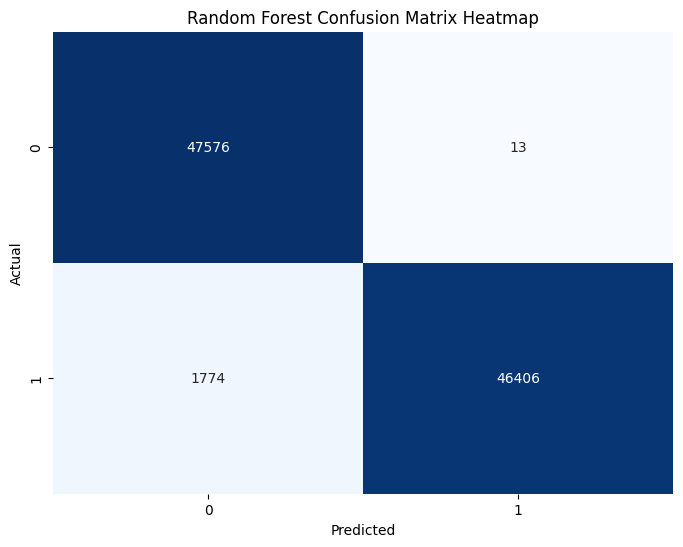

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=200, max_depth=2, random_state=42)

# Cross-validation with accuracy scoring
cv_scores = cross_val_score(rf_model, X_train_pca, y_train, cv=5, scoring='accuracy')
print(f"\nCross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Fit the model
rf_model.fit(X_train_pca, y_train)

# Predictions on the training set
y_train_pred = rf_model.predict(X_train_pca)

# Predictions on the test set
y_test_pred = rf_model.predict(X_test_pca)

# Evaluation metrics for training data
print("\nTraining Classification Report:")
print(classification_report(y_train, y_train_pred))

# Evaluation metrics for testing data
print("\nTesting Classification Report:")
print(classification_report(y_test, y_test_pred))

# Confusion matrix for testing data
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix Heatmap')
plt.show()

with open('Random_Forest_Classifier.pkl', 'wb') as file:
    pickle.dump(dt_model, file)


Cross-Validation Accuracy: 0.9987 ± 0.0002

Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110933
           1       1.00      1.00      1.00    112525

    accuracy                           1.00    223458
   macro avg       1.00      1.00      1.00    223458
weighted avg       1.00      1.00      1.00    223458


Testing Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     47589
           1       1.00      1.00      1.00     48180

    accuracy                           1.00     95769
   macro avg       1.00      1.00      1.00     95769
weighted avg       1.00      1.00      1.00     95769



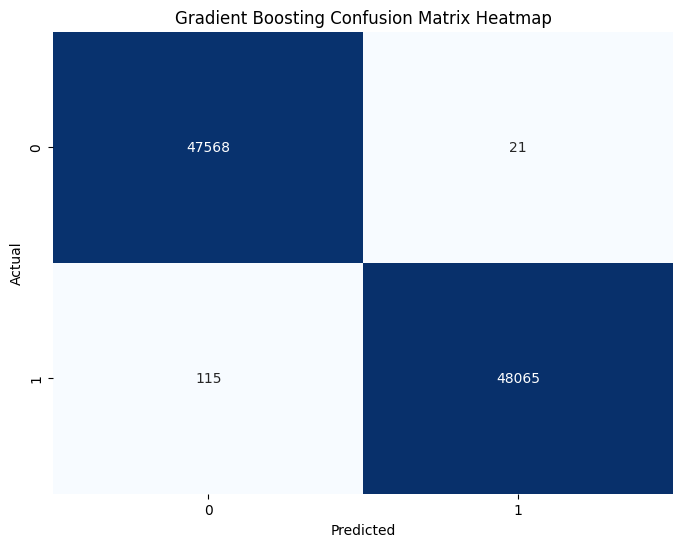

In [21]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

# Initialize Gradient Boosting model
gbm_model = GradientBoostingClassifier(n_estimators=50,max_depth=3, random_state=42)

imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train_pca)
X_test_imputed = imputer.transform(X_test_pca)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Cross-validation with accuracy scoring
cv_scores = cross_val_score(gbm_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"\nCross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Fit the model
gbm_model.fit(X_train_scaled, y_train)

# Predictions on the training set
y_train_pred = gbm_model.predict(X_train_scaled)

# Predictions on the test set
y_test_pred = gbm_model.predict(X_test_scaled)

# Evaluation metrics for training data
print("\nTraining Classification Report:")
print(classification_report(y_train, y_train_pred))

# Evaluation metrics for testing data
print("\nTesting Classification Report:")
print(classification_report(y_test, y_test_pred))

# Confusion matrix for testing data
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Gradient Boosting Confusion Matrix Heatmap')
plt.show()

with open('Gradient_Boosting_Classifier.pkl', 'wb') as file:
    pickle.dump(dt_model, file)

In [22]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle

# Initialize XGBoost Classifier
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Train the model
model.fit(X_train_pca, y_train)

# Predictions
y_train_pred = model.predict(X_train_pca)
y_test_pred = model.predict(X_test_pca)

# Classification Reports
print("Training Classification Report:\n")
print(classification_report(y_train, y_train_pred))

print("\nTest Classification Report:\n")
print(classification_report(y_test, y_test_pred))

# Accuracy Scores
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

# Confusion Matrix
print("\nConfusion Matrix (Test):\n")
print(confusion_matrix(y_test, y_test_pred))

# Save the model
with open('XGBoost_Classifier.pkl', 'wb') as file:
    pickle.dump(model, file)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:02:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Training Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110933
           1       1.00      1.00      1.00    112525

    accuracy                           1.00    223458
   macro avg       1.00      1.00      1.00    223458
weighted avg       1.00      1.00      1.00    223458


Test Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     47589
           1       1.00      1.00      1.00     48180

    accuracy                           1.00     95769
   macro avg       1.00      1.00      1.00     95769
weighted avg       1.00      1.00      1.00     95769

Training Accuracy: 1.00
Test Accuracy: 1.00

Confusion Matrix (Test):

[[47589     0]
 [    2 48178]]


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:02:51] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:02:57] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Training Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.99      0.98    110933
           1       0.99      0.96      0.98    112525

    accuracy                           0.98    223458
   macro avg       0.98      0.98      0.98    223458
weighted avg       0.98      0.98      0.98    223458


Test Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     47589
           1       0.99      0.96      0.98     48180

    accuracy                           0.98     95769
   macro avg       0.98      0.98      0.98     95769
weighted avg       0.98      0.98      0.98     95769

Training Accuracy: 0.98
Test Accuracy: 0.98


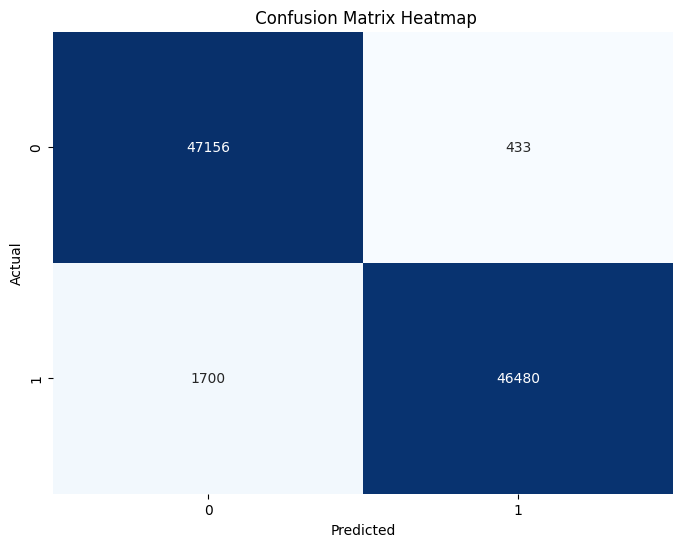

In [23]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV
import pickle

# Define XGBoost model
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Define hyperparameters to tune
param_grid = {
    'n_estimators': [200],
    'learning_rate': [0.01],
    'max_depth': [2],
    'subsample': [0.7],
    'colsample_bytree': [0.7],
    'gamma': [0.1]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid,
                           scoring='accuracy', cv=5, verbose=2, n_jobs=-1)

# Fit GridSearchCV
grid_search.fit(X_train_pca, y_train)

# Get the best parameters
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

# Train the model
best_model.fit(X_train_pca, y_train)

# Predictions
y_train_pred = best_model.predict(X_train_pca)
y_test_pred = best_model.predict(X_test_pca)

# Classification Reports
print("Training Classification Report:\n")
print(classification_report(y_train, y_train_pred))

print("\nTest Classification Report:\n")
print(classification_report(y_test, y_test_pred))

# Accuracy Scores
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")


# Display confusion matrix for testing data
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(' Confusion Matrix Heatmap')
plt.show()
# Save the best model
with open('XGBoost_Classifier_best_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)



Cross-Validation Accuracy: 1.0000 ± 0.0000

Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110933
           1       1.00      1.00      1.00    112525

    accuracy                           1.00    223458
   macro avg       1.00      1.00      1.00    223458
weighted avg       1.00      1.00      1.00    223458


Testing Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     47589
           1       1.00      1.00      1.00     48180

    accuracy                           1.00     95769
   macro avg       1.00      1.00      1.00     95769
weighted avg       1.00      1.00      1.00     95769



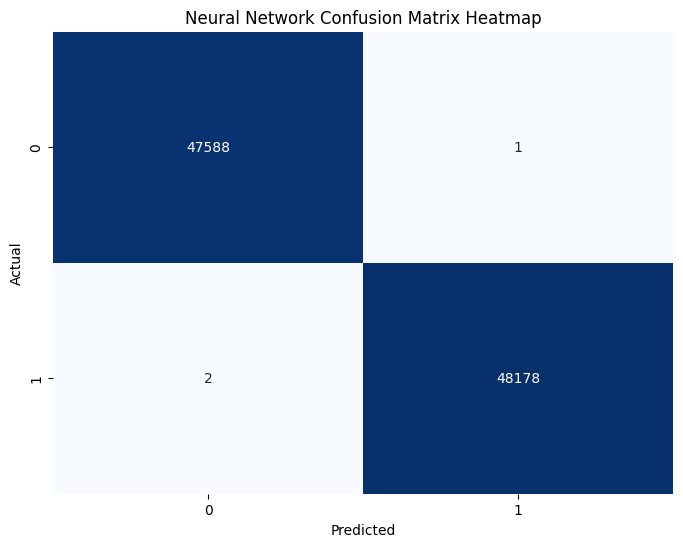

In [24]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize Neural Network
mlp_model = MLPClassifier(
    hidden_layer_sizes=(30,),
    max_iter=100,
    alpha=0.001,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.2
)

# Cross-validation with accuracy scores
cv_scores = cross_val_score(mlp_model, X_train_pca, y_train, cv=5, scoring='accuracy')
print(f"\nCross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Fit the model
mlp_model.fit(X_train_pca, y_train)

# Predictions on the training set
y_train_pred = mlp_model.predict(X_train_pca)

# Predictions on the test set
y_test_pred = mlp_model.predict(X_test_pca)

# Evaluation metrics for training data
print("\nTraining Classification Report:")
print(classification_report(y_train, y_train_pred))

# Evaluation metrics for testing data
print("\nTesting Classification Report:")
print(classification_report(y_test, y_test_pred))

# Display Confusion matrix for testing data
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Neural Network Confusion Matrix Heatmap')
plt.show()


Cross-Validation Accuracy: 1.0000 ± 0.0000

Test Set Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     47589
           1       1.00      1.00      1.00     48180

    accuracy                           1.00     95769
   macro avg       1.00      1.00      1.00     95769
weighted avg       1.00      1.00      1.00     95769



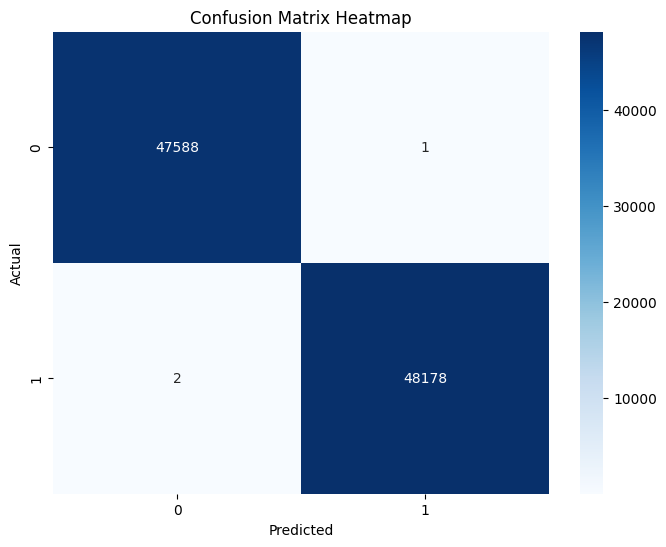

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize Logistic Regression
model = LogisticRegression(solver='saga', C=1.0, max_iter=500,random_state=42)

# Train the model
model.fit(X_train_pca, y_train)

# Cross-validation scores
cv_scores = cross_val_score(model, X_train_pca, y_train, cv=5)
print(f"\nCross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Predictions
y_pred = model.predict(X_test_pca)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Set Accuracy: {accuracy:.4f}")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
import pickle

# Initialize Logistic Regression Model with Hyperparameters
model = LogisticRegression(
    C=0.1,
    penalty='l2',
    solver='liblinear',
    random_state=42
)

# Cross-Validation scores
cv_scores = cross_val_score(model, X_train_pca, y_train, cv=5, scoring='accuracy')
print(f"\nCross-Validation Scores: {cv_scores}")
print(f"Average CV Score: {cv_scores.mean():.4f}")

# Train the Model
model.fit(X_train_pca, y_train)

# Predictions
y_pred_lr_train = model.predict(X_train_pca)
y_pred_lr_test = model.predict(X_test_pca)

# Classification Reports
print("\nLogistic Regression Classification Report (Train):")
print(classification_report(y_train, y_pred_lr_train))

print("\nLogistic Regression Classification Report (Test):")
print(classification_report(y_test, y_pred_lr_test))

# Save Model
with open('logistic_regression_model.pkl', 'wb') as file:
    pickle.dump(model, file)


Cross-Validation Scores: [0.99997762 1.         0.99997762 0.99995525 0.99995525]
Average CV Score: 1.0000

Logistic Regression Classification Report (Train):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110933
           1       1.00      1.00      1.00    112525

    accuracy                           1.00    223458
   macro avg       1.00      1.00      1.00    223458
weighted avg       1.00      1.00      1.00    223458


Logistic Regression Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     47589
           1       1.00      1.00      1.00     48180

    accuracy                           1.00     95769
   macro avg       1.00      1.00      1.00     95769
weighted avg       1.00      1.00      1.00     95769

